In [1]:
import cloudViewer as cv3d
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import sys

# only needed for tutorial, monkey patches visualization
sys.path.append('..')
import cloudViewer_tutorial as cv3dtut
# change to True if you want to interact with the visualization windows
cv3dtut.interactive = not "CI" in os.environ

Using external CloudViewer-ML in /root/CloudViewer-ML


# Voxelization
Point clouds and triangle meshes are very flexible, but irregular, geometry types. The voxel grid is another geometry type in 3D that is defined on a regular 3D grid, whereas a voxel can be thought of as the 3D counterpart to the pixel in 2D. CloudViewer has the geometry type `VoxelGrid` that can be used to work with voxel grids.

## From triangle mesh
CloudViewer provides the method `create_from_triangle_mesh` that creates a voxel grid from a triangle mesh. It returns a voxel grid where all voxels that are intersected by a triangle are set to `1`, all others are set to `0`. The argument `voxel_size` defines the resolution of the voxel grid.

input
[CloudViewer WARNING] GLFW Error: X11: The DISPLAY environment variable is missing
[CloudViewer WARNING] GLFW initialized for headless rendering.


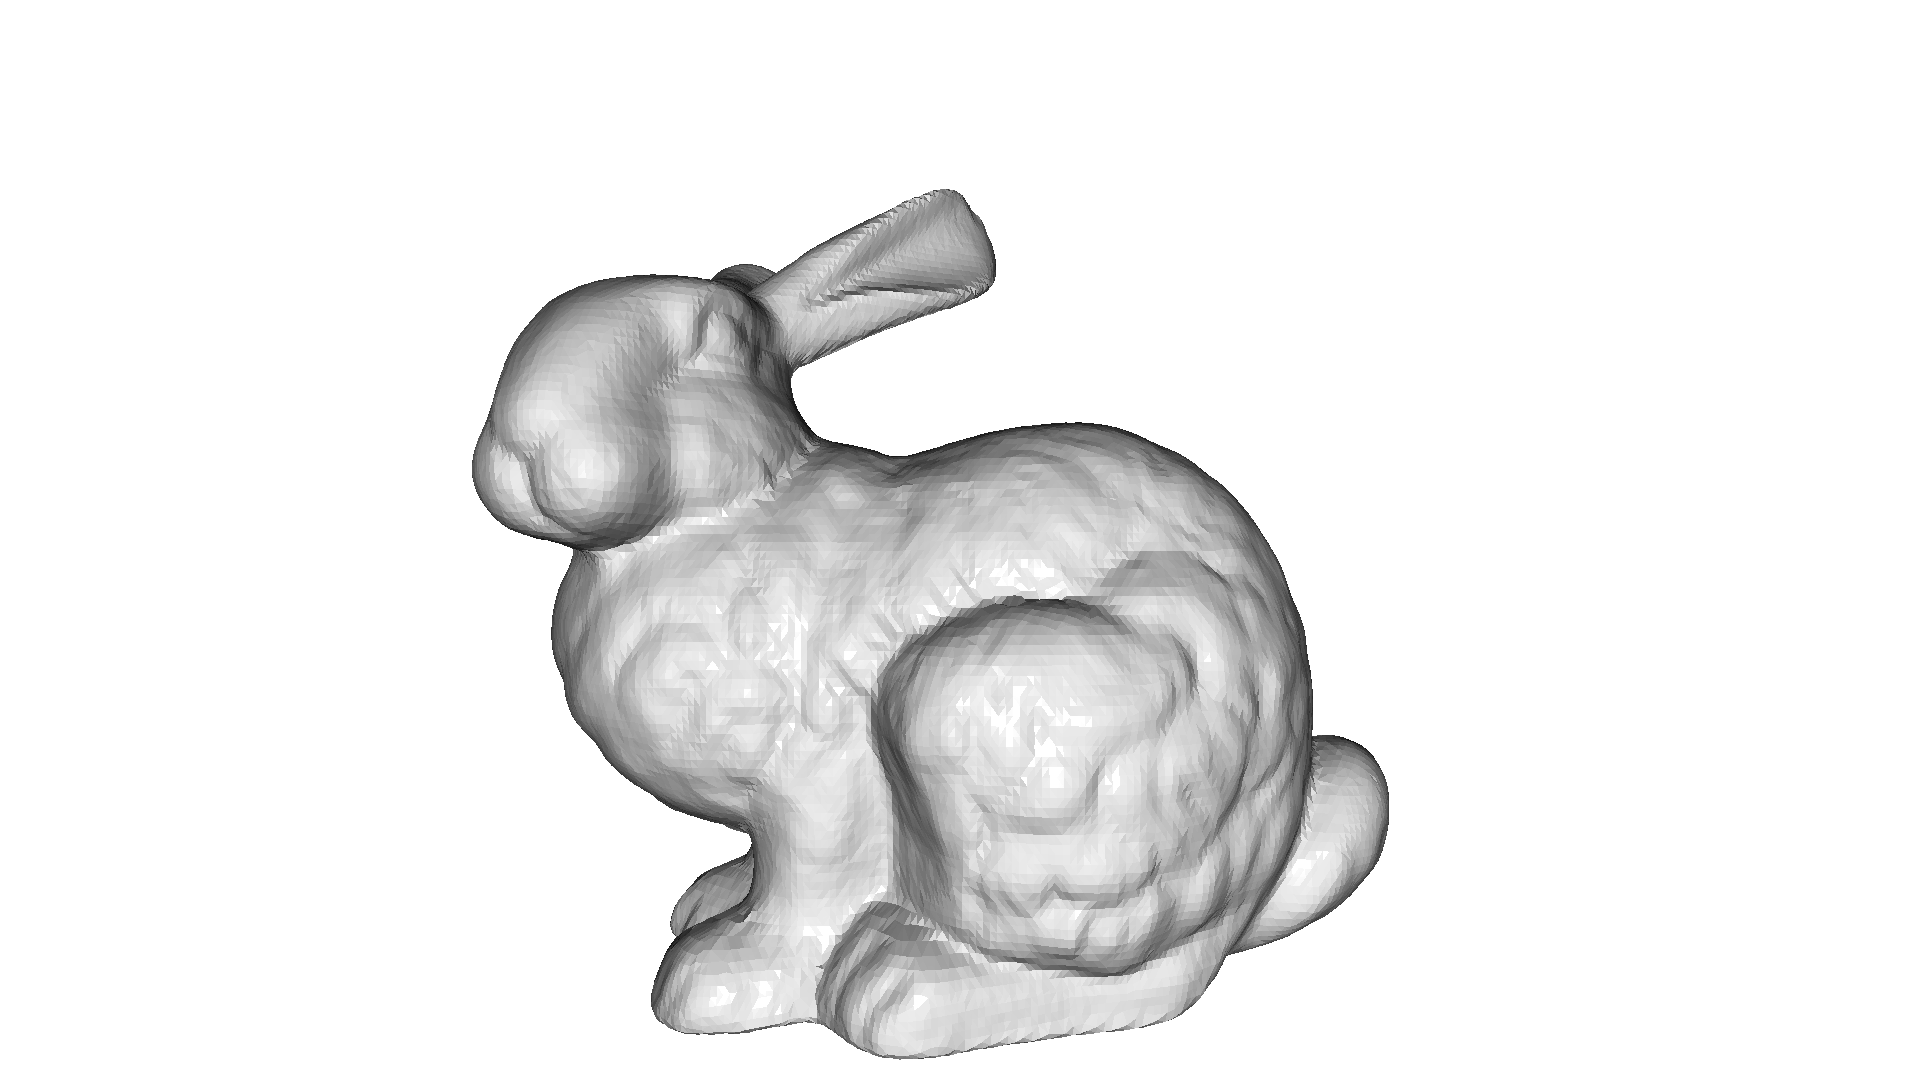

voxelization
[CloudViewer WARNING] GLFW initialized for headless rendering.


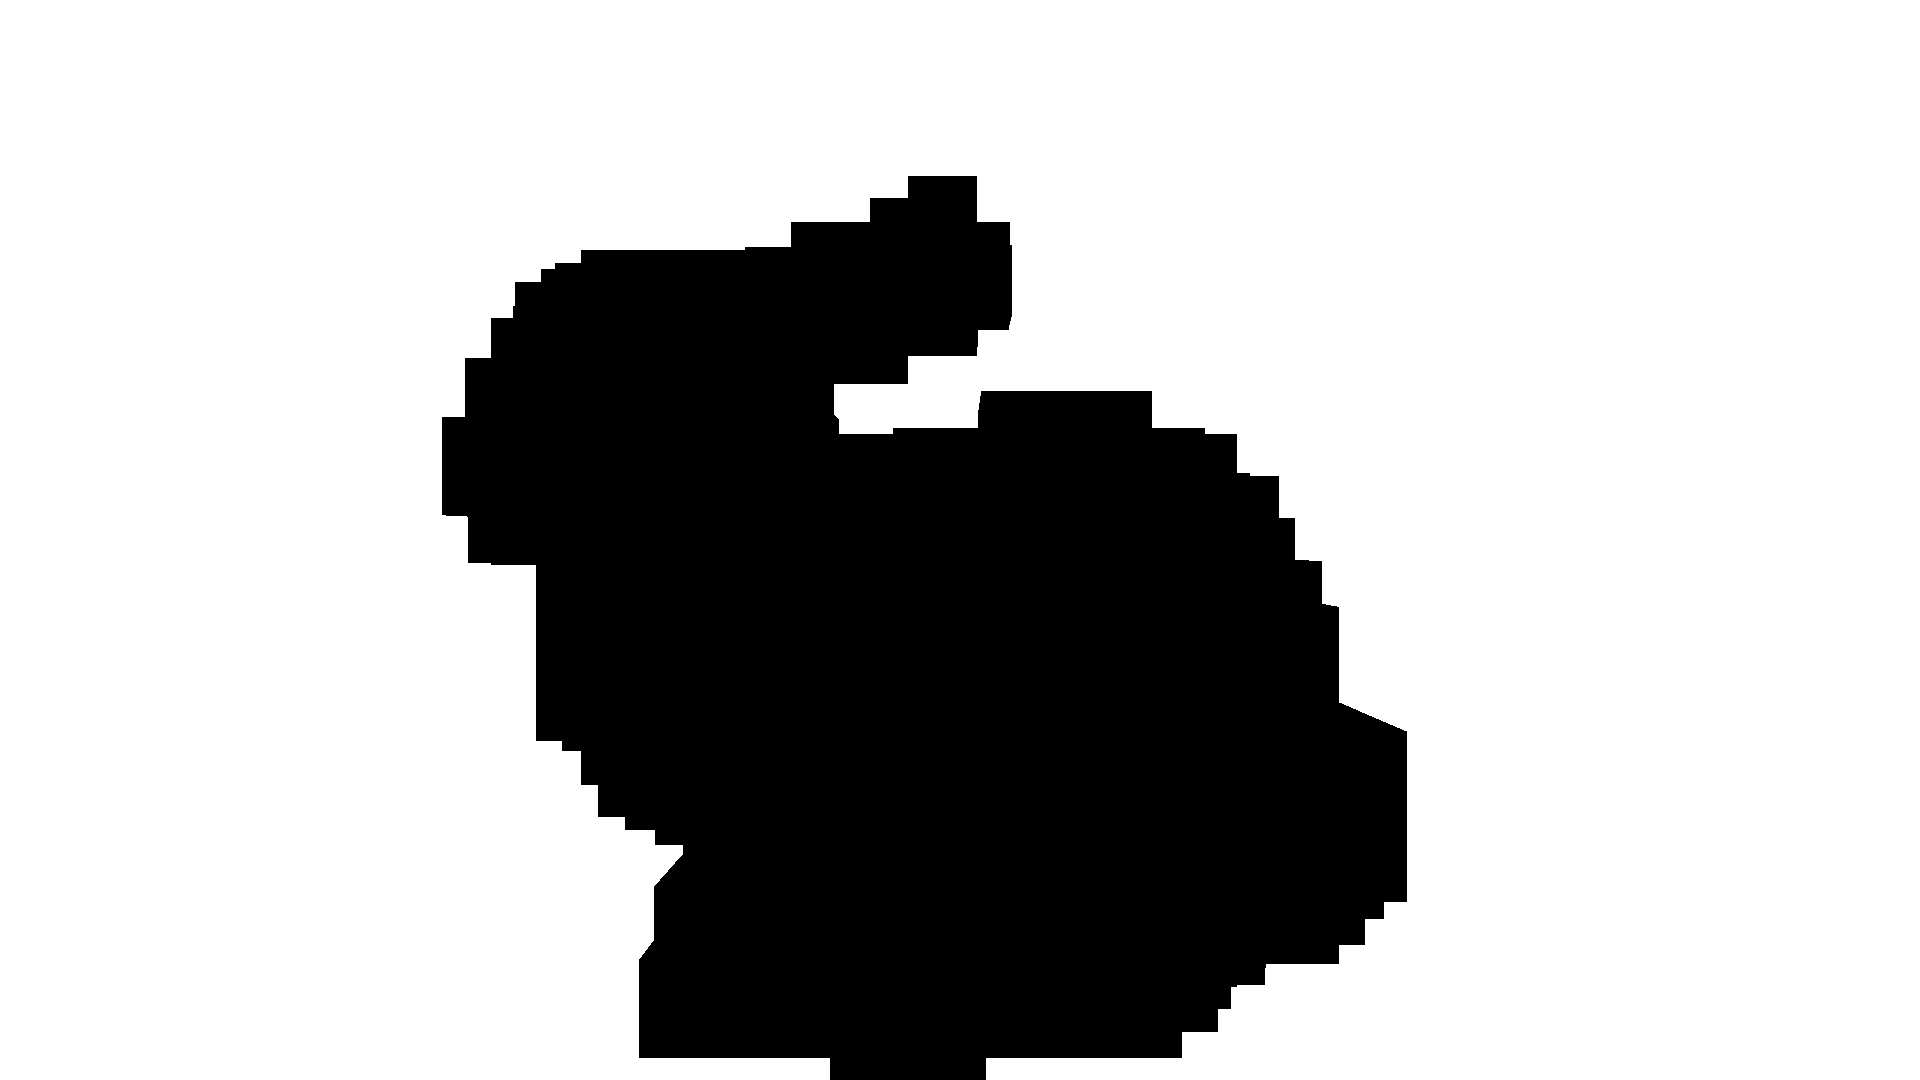

In [2]:
print('input')
bunny = cv3d.data.BunnyMesh()
mesh = cv3d.io.read_triangle_mesh(bunny.path)
mesh.compute_vertex_normals()
# fit to unit cube
mesh.scale(1 / np.max(mesh.get_max_bound() - mesh.get_min_bound()),
           center=mesh.get_center())
cv3d.visualization.draw_geometries([mesh])

print('voxelization')
voxel_grid = cv3d.geometry.VoxelGrid.create_from_triangle_mesh(mesh,
                                                               voxel_size=0.05)
cv3d.visualization.draw_geometries([voxel_grid])

## From point cloud
The voxel grid can also be created from a point cloud using the method `create_from_point_cloud`. A voxel is occupied if at least one point of the point cloud is within the voxel. The color of the voxel is the average of all the points within the voxel. The argument `voxel_size` defines the resolution of the voxel grid.

input


[CloudViewer WARNING] GLFW initialized for headless rendering.


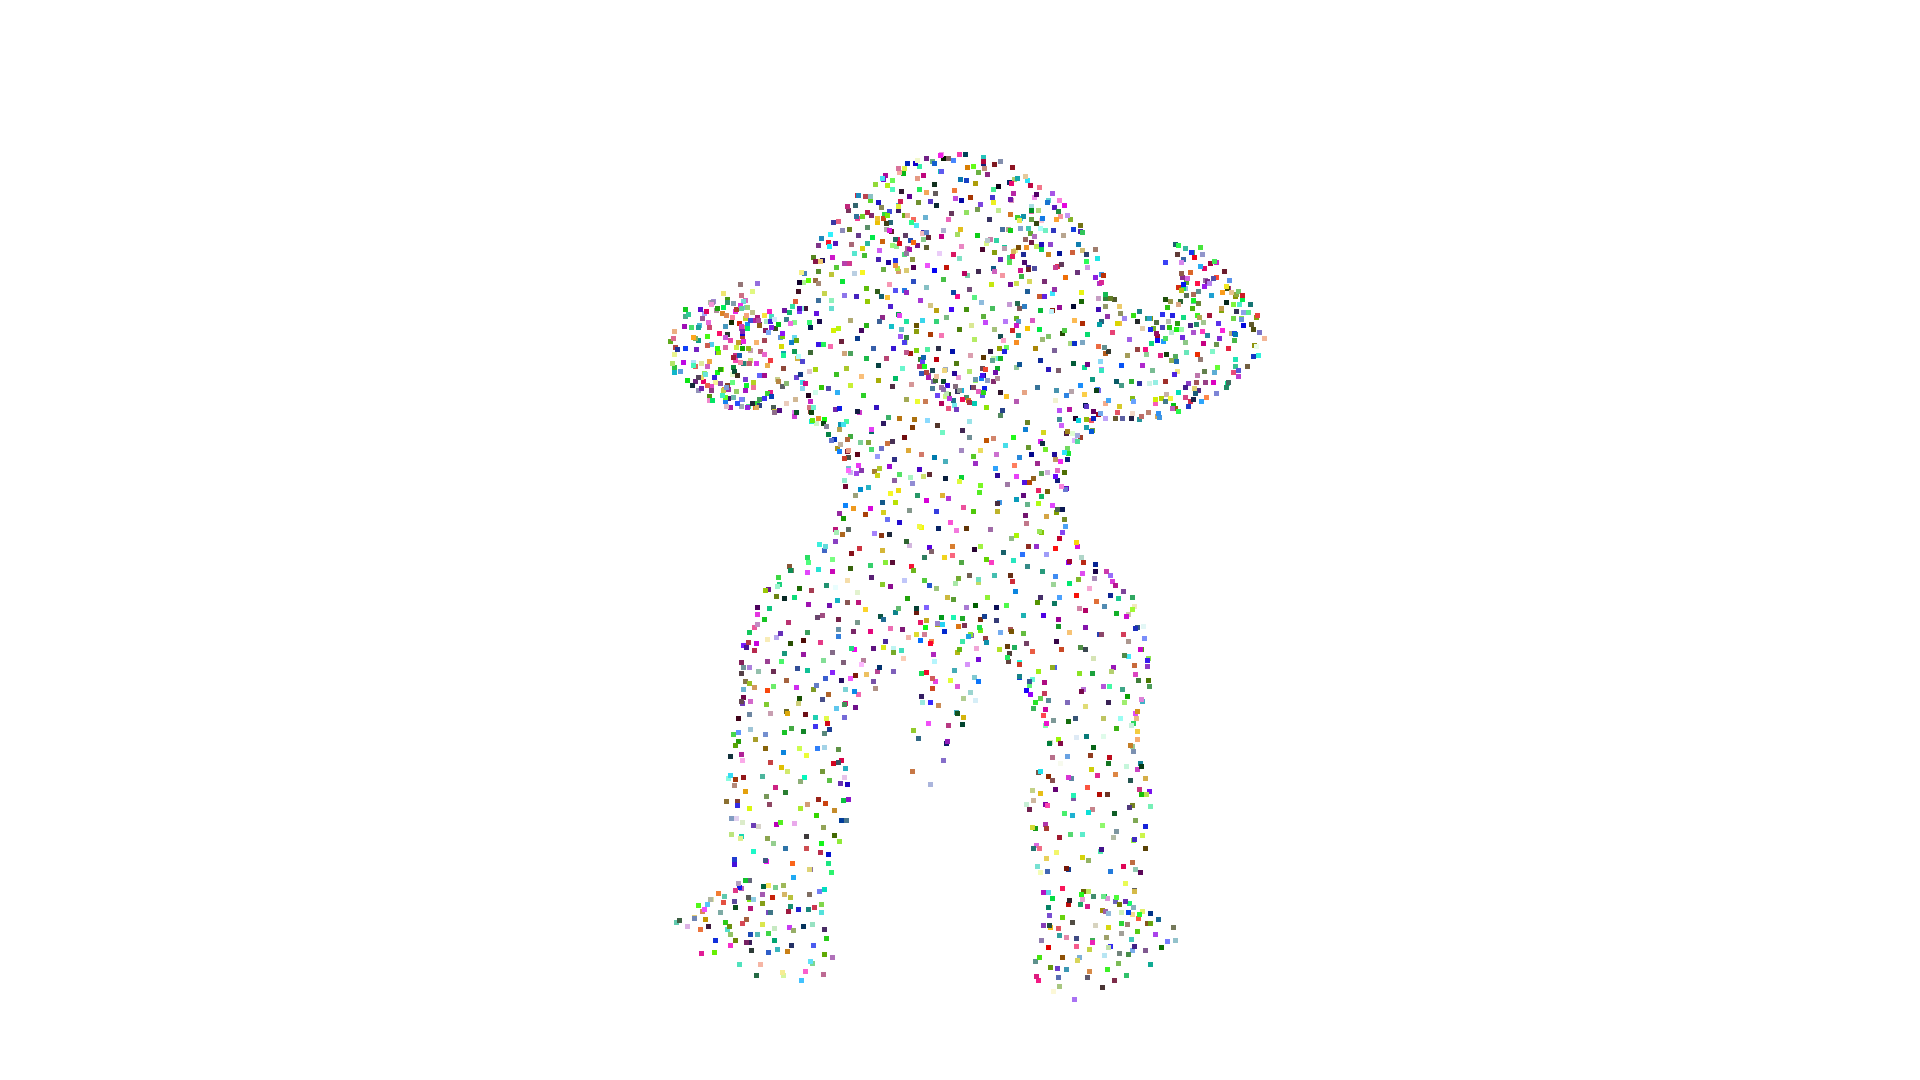

voxelization
[CloudViewer WARNING] GLFW initialized for headless rendering.


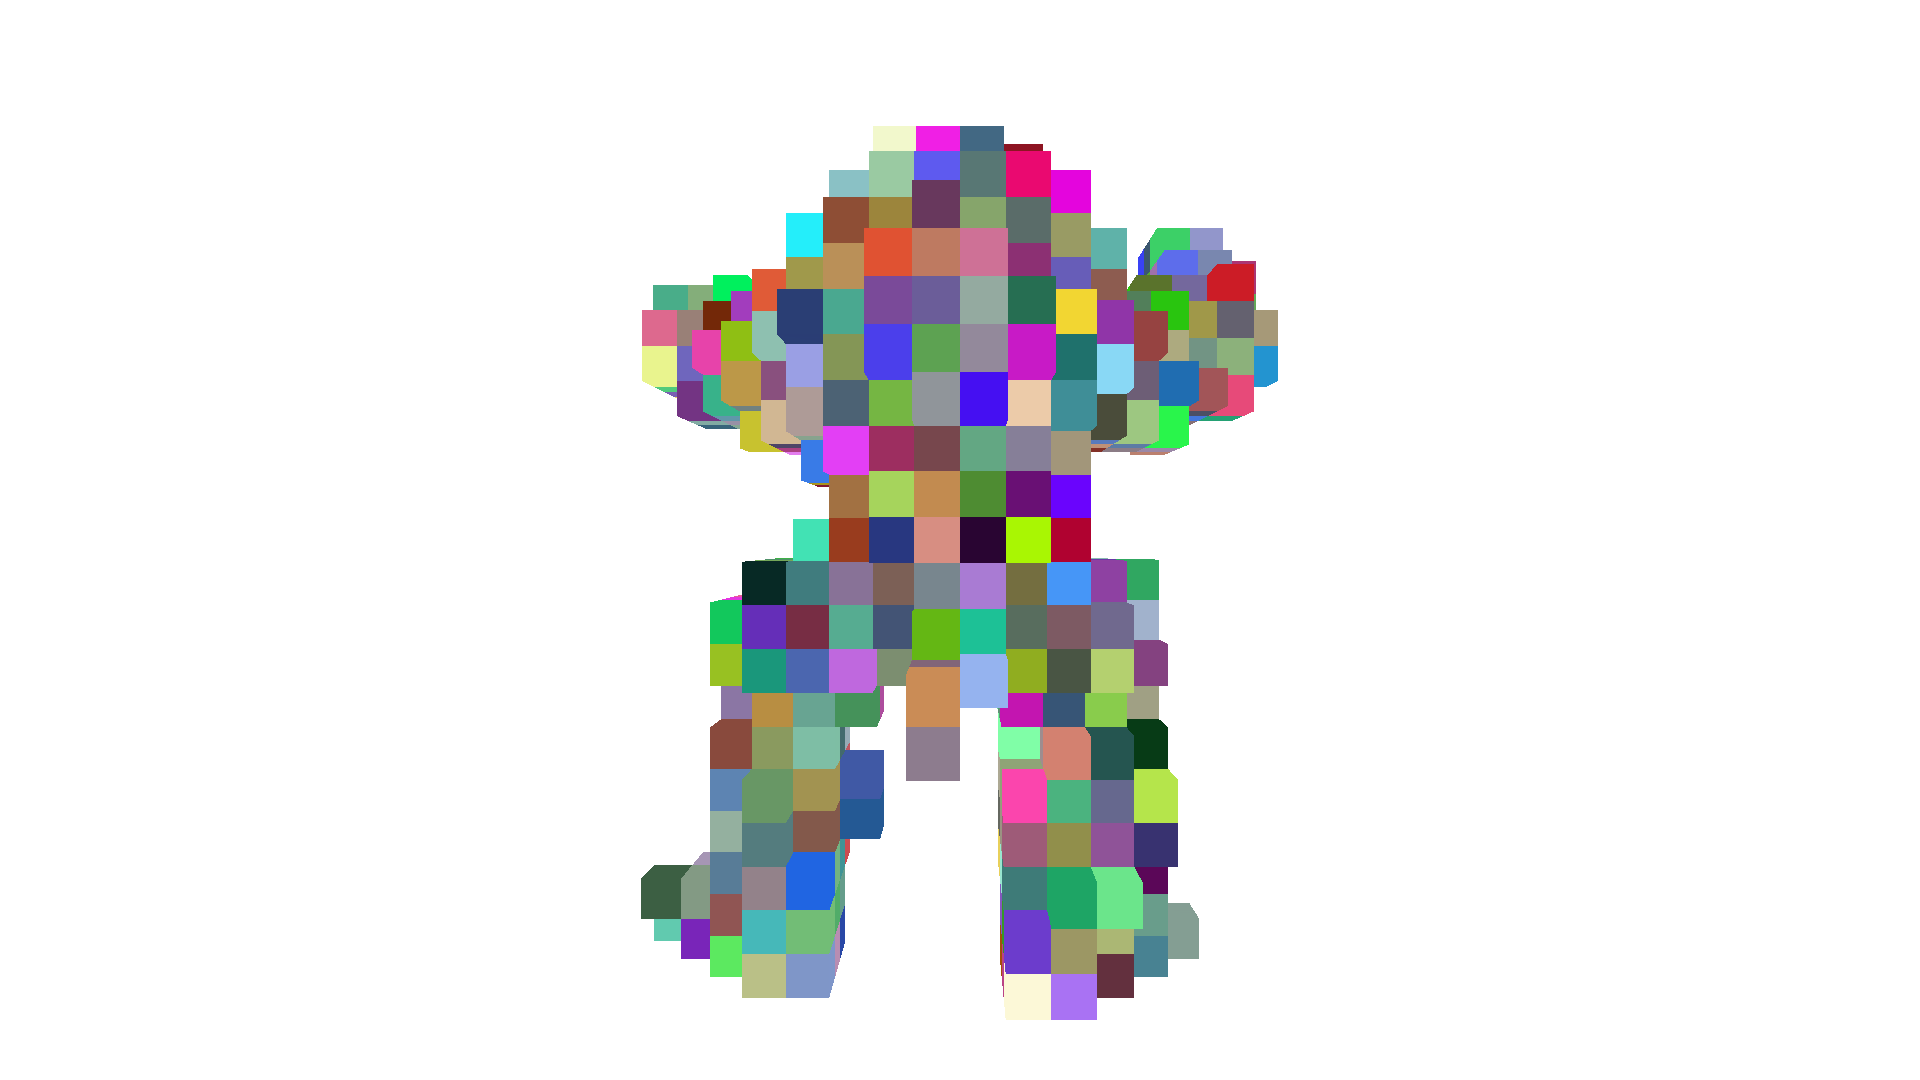

In [3]:
print('input')
N = 2000
armadillo_data = cv3d.data.ArmadilloMesh()
pcd = cv3d.io.read_triangle_mesh(
    armadillo_data.path).sample_points_poisson_disk(N)
# fit to unit cube
pcd.scale(1 / np.max(pcd.get_max_bound() - pcd.get_min_bound()),
          center=pcd.get_center())
pcd.set_colors(cv3d.utility.Vector3dVector(np.random.uniform(0, 1,
                                                             size=(N, 3))))
cv3d.visualization.draw_geometries([pcd])

print('voxelization')
voxel_grid = cv3d.geometry.VoxelGrid.create_from_point_cloud(pcd,
                                                             voxel_size=0.05)
cv3d.visualization.draw_geometries([voxel_grid])

## Inclusion test
The voxel grid can also be used to test if points are within an occupied voxel. The method `check_if_included` takes a `(n,3)` array as input and outputs a `bool` array.

In [4]:
queries = np.asarray(pcd.get_points())
output = voxel_grid.check_if_included(cv3d.utility.Vector3dVector(queries))
print(output[:10])

[True, True, True, True, True, True, True, True, True, True]


## Voxel carving
The methods `create_from_point_cloud` and `create_from_triangle_mesh` create occupied voxels only on the surface of the geometry. It is however possible to carve a voxel grid from a number of depth maps or silhouettes. CloudViewer provides the methods `carve_depth_map` and `carve_silhouette` for voxel carving.

The code below demonstrates the usage by first rendering depthmaps from a geometry and using those depthmaps to carve a dense voxel grid. The result is a filled voxel grid of the given shape.

In [5]:
def xyz_spherical(xyz):
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    r = np.sqrt(x * x + y * y + z * z)
    r_x = np.arccos(y / r)
    r_y = np.arctan2(z, x)
    return [r, r_x, r_y]


def get_rotation_matrix(r_x, r_y):
    rot_x = np.asarray([[1, 0, 0], [0, np.cos(r_x), -np.sin(r_x)],
                        [0, np.sin(r_x), np.cos(r_x)]])
    rot_y = np.asarray([[np.cos(r_y), 0, np.sin(r_y)], [0, 1, 0],
                        [-np.sin(r_y), 0, np.cos(r_y)]])
    return rot_y.dot(rot_x)


def get_extrinsic(xyz):
    rvec = xyz_spherical(xyz)
    r = get_rotation_matrix(rvec[1], rvec[2])
    t = np.asarray([0, 0, 2]).transpose()
    trans = np.eye(4)
    trans[:3, :3] = r
    trans[:3, 3] = t
    return trans


def preprocess(model):
    min_bound = model.get_min_bound()
    max_bound = model.get_max_bound()
    center = min_bound + (max_bound - min_bound) / 2.0
    scale = np.linalg.norm(max_bound - min_bound) / 2.0
    vertices = np.asarray(model.get_vertices())
    vertices -= center
    model.set_vertices(cv3d.utility.Vector3dVector(vertices / scale))
    return model


def voxel_carving(mesh,
                  cubic_size,
                  voxel_resolution,
                  w=300,
                  h=300,
                  use_depth=True,
                  surface_method='pointcloud'):
    mesh.compute_vertex_normals()
    camera_sphere = cv3d.geometry.ccMesh.create_sphere()

    # setup dense voxel grid
    voxel_carving = cv3d.geometry.VoxelGrid.create_dense(
        width=cubic_size,
        height=cubic_size,
        depth=cubic_size,
        voxel_size=cubic_size / voxel_resolution,
        origin=[-cubic_size / 2.0, -cubic_size / 2.0, -cubic_size / 2.0],
        color=[1.0, 0.7, 0.0])

    # rescale geometry
    camera_sphere = preprocess(camera_sphere)
    mesh = preprocess(mesh)

    # setup visualizer to render depthmaps
    vis = cv3d.visualization.Visualizer()
    vis.create_window(width=w, height=h, visible=False)
    vis.add_geometry(mesh)
    vis.get_render_option().mesh_show_back_face = True
    ctr = vis.get_view_control()
    param = ctr.convert_to_pinhole_camera_parameters()

    # carve voxel grid
    pcd_agg = cv3d.geometry.ccPointCloud()
    centers_pts = np.zeros((len(camera_sphere.get_vertices()), 3))
    for cid, xyz in enumerate(camera_sphere.get_vertices()):
        # get new camera pose
        trans = get_extrinsic(xyz)
        param.extrinsic = trans
        c = np.linalg.inv(trans).dot(np.asarray([0, 0, 0, 1]).transpose())
        centers_pts[cid, :] = c[:3]
        ctr.convert_from_pinhole_camera_parameters(param)

        # capture depth image and make a point cloud
        vis.poll_events()
        vis.update_renderer()
        depth = vis.capture_depth_float_buffer(False)
        pcd_agg += cv3d.geometry.ccPointCloud.create_from_depth_image(
            cv3d.geometry.Image(depth),
            param.intrinsic,
            param.extrinsic,
            depth_scale=1)

        # depth map carving method
        if use_depth:
            voxel_carving.carve_depth_map(cv3d.geometry.Image(depth), param)
        else:
            voxel_carving.carve_silhouette(cv3d.geometry.Image(depth), param)
        print("Carve view %03d/%03d" %
              (cid + 1, len(camera_sphere.get_vertices())))
    vis.destroy_window()

    # add voxel grid survace
    print('Surface voxel grid from %s' % surface_method)
    if surface_method == 'pointcloud':
        voxel_surface = cv3d.geometry.VoxelGrid.create_from_point_cloud_within_bounds(
            pcd_agg,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=(-cubic_size / 2, -cubic_size / 2, -cubic_size / 2),
            max_bound=(cubic_size / 2, cubic_size / 2, cubic_size / 2))
    elif surface_method == 'mesh':
        voxel_surface = cv3d.geometry.VoxelGrid.create_from_triangle_mesh_within_bounds(
            mesh,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=(-cubic_size / 2, -cubic_size / 2, -cubic_size / 2),
            max_bound=(cubic_size / 2, cubic_size / 2, cubic_size / 2))
    else:
        raise Exception('invalid surface method')
    voxel_carving_surface = voxel_surface + voxel_carving

    return voxel_carving_surface, voxel_carving, voxel_surface

In [6]:
armadillo_data = cv3d.data.ArmadilloMesh()
mesh = cv3d.io.read_triangle_mesh(armadillo_data.path)
mesh.compute_vertex_normals()

visualization = True
cubic_size = 2.0
voxel_resolution = 128.0

voxel_grid, voxel_carving, voxel_surface = voxel_carving(
    mesh, cubic_size, voxel_resolution)

[CloudViewer WARNING] GLFW initialized for headless rendering.


Carve view 001/762
Carve view 002/762
Carve view 003/762


Carve view 004/762
Carve view 005/762


Carve view 006/762
Carve view 007/762
Carve view 008/762


Carve view 009/762
Carve view 010/762


...

Carve view 750/762
Carve view 751/762
Carve view 752/762


Carve view 753/762
Carve view 754/762
Carve view 755/762


Carve view 756/762
Carve view 757/762


Carve view 758/762
Carve view 759/762


Carve view 760/762
Carve view 761/762
Carve view 762/762
Surface voxel grid from pointcloud


surface voxels
VoxelGrid with 17218 voxels.
[CloudViewer WARNING] GLFW initialized for headless rendering.


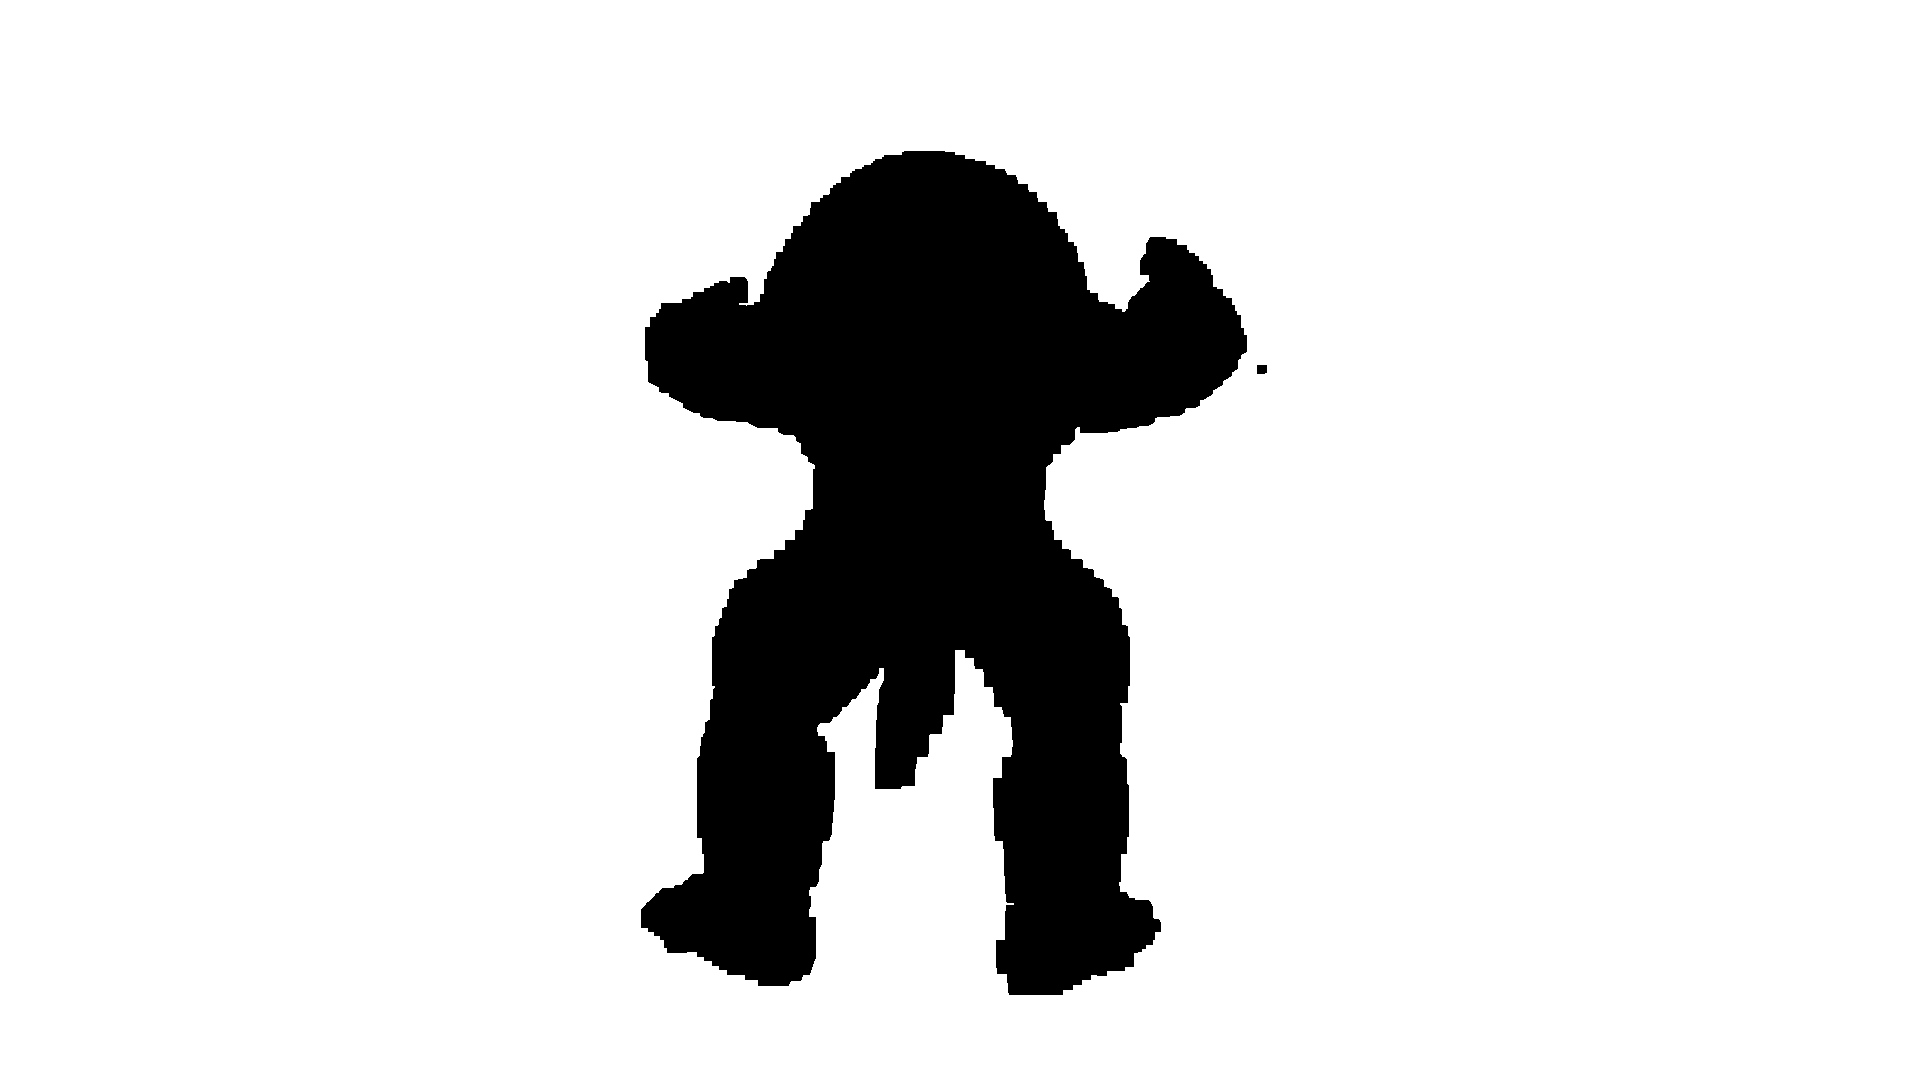

carved voxels
VoxelGrid with 48379 voxels.
[CloudViewer WARNING] GLFW initialized for headless rendering.


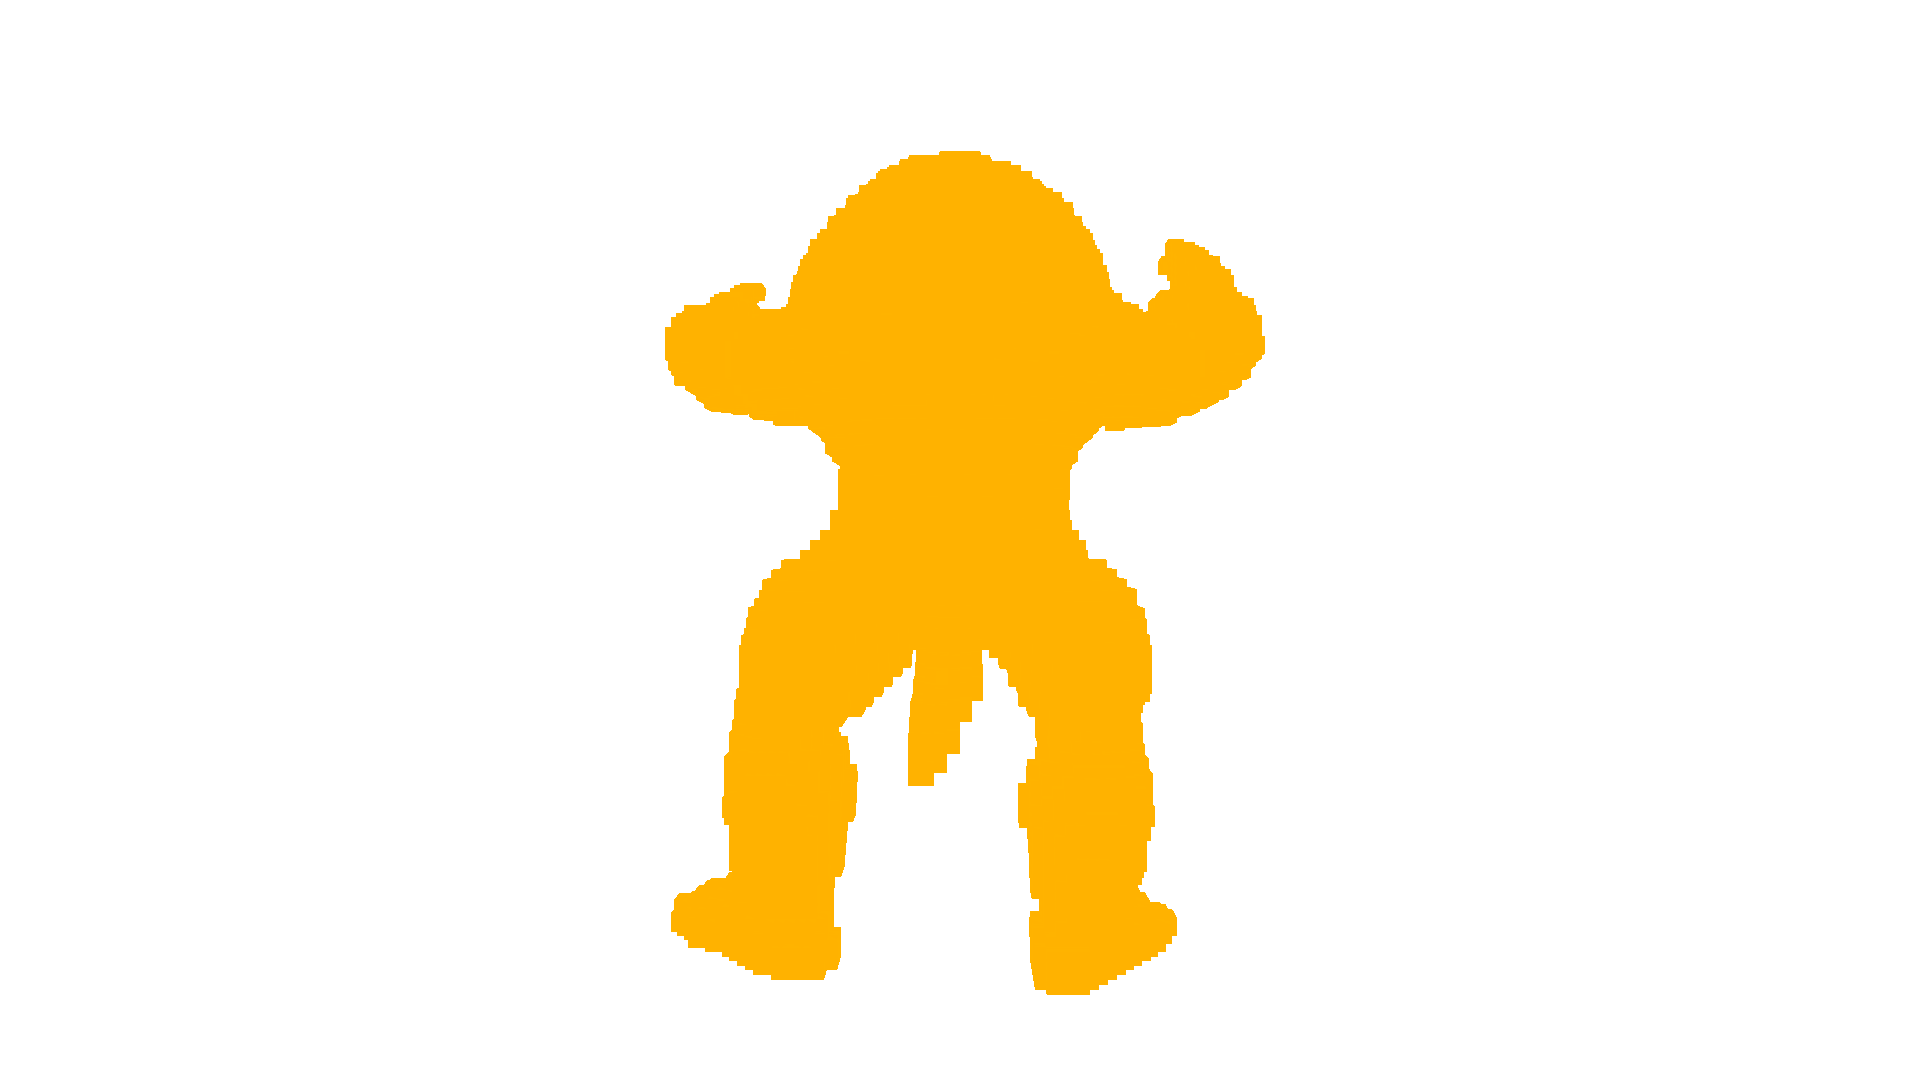

combined voxels (carved + surface)
VoxelGrid with 50793 voxels.
[CloudViewer WARNING] GLFW initialized for headless rendering.


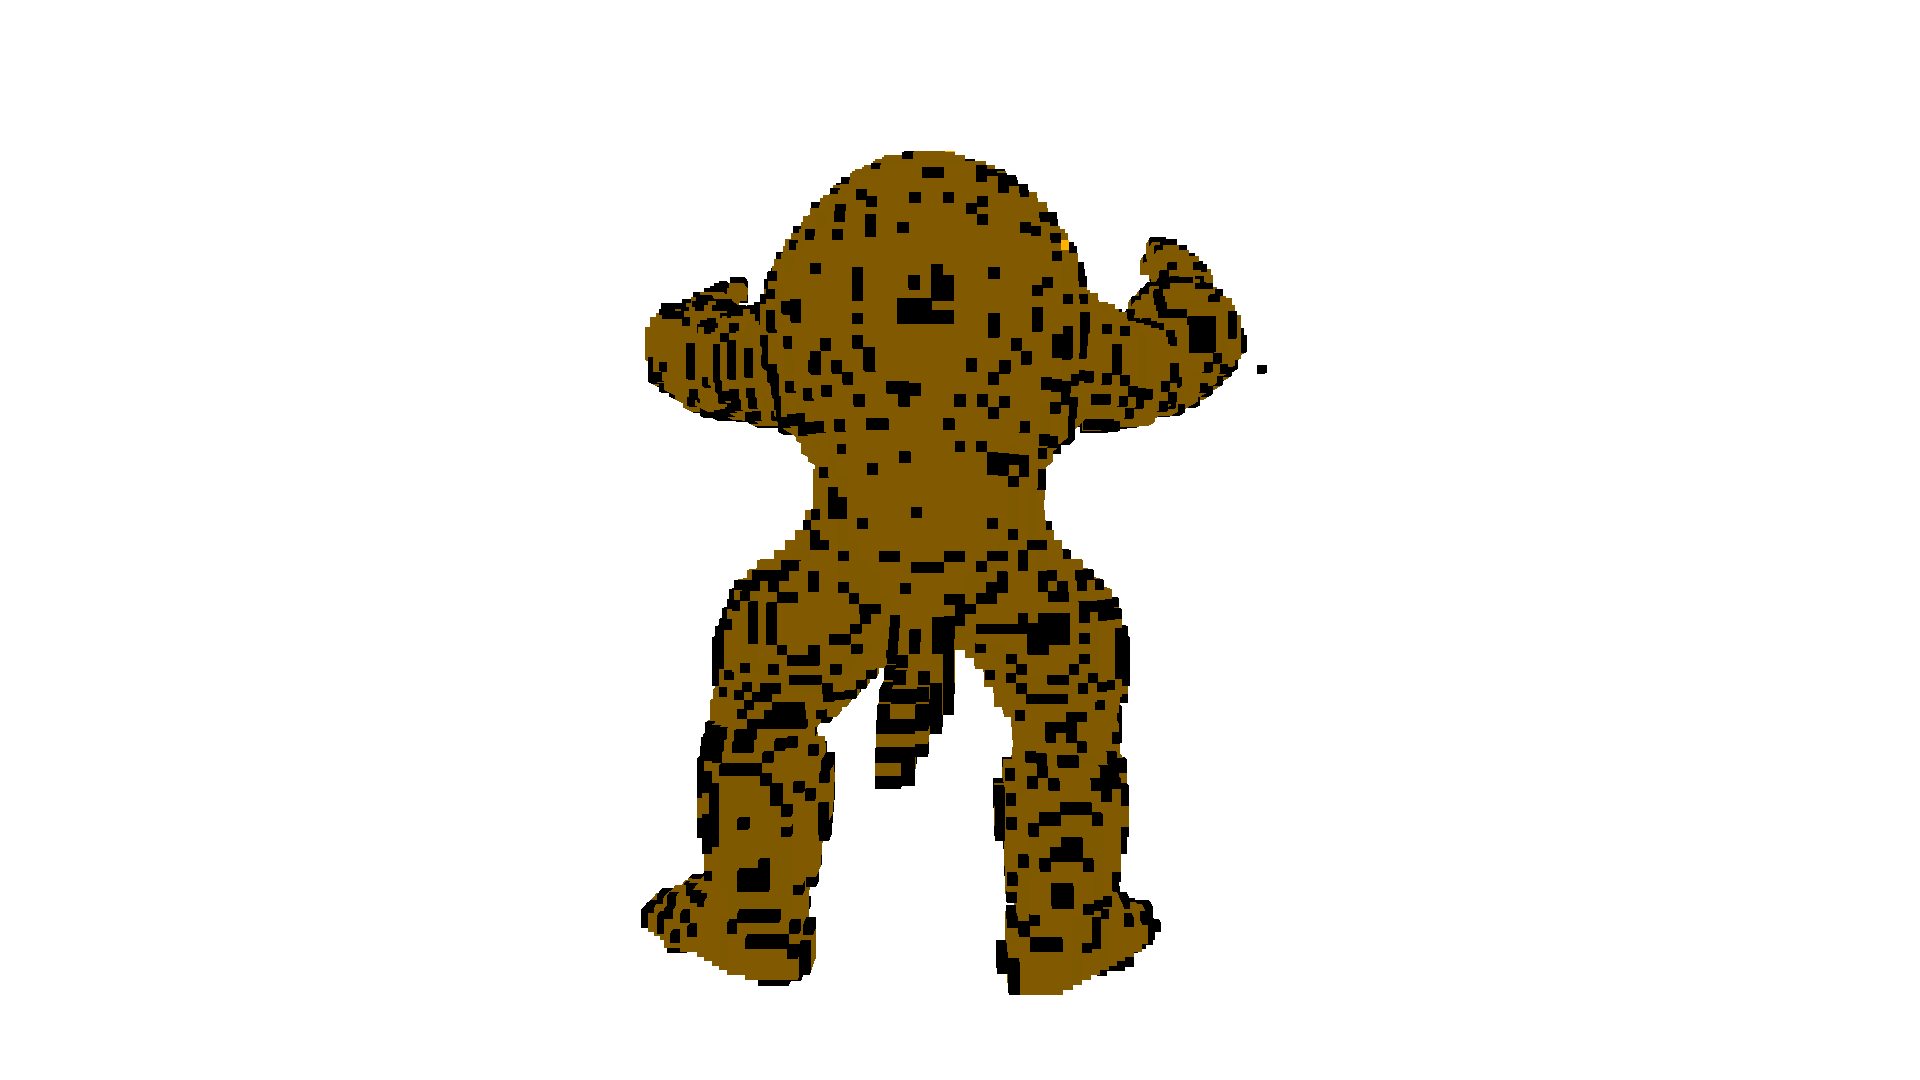

In [7]:
print("surface voxels")
print(voxel_surface)
cv3d.visualization.draw_geometries([voxel_surface])

print("carved voxels")
print(voxel_carving)
cv3d.visualization.draw_geometries([voxel_carving])

print("combined voxels (carved + surface)")
print(voxel_grid)
cv3d.visualization.draw_geometries([voxel_grid])